![header](https://drive.google.com/uc?export=view&id=1KuEspEp7OwqGw6uMRJvYE6BVE-Zo-8JF)

 <h1> <div align="center"> Dr. David Antonio-Torres</div> </h1>

# Redes Neuronales para Clasificación Multiclase

## Entorno de ejecución y referencias

🔗 **Repositorio GitHub:** [https://github.com/joelbecv/MNA_WORKSPACE](https://github.com/joelbecv/MNA_WORKSPACE)  
📁 **Archivo:** `4.3 deep_learning_keras_a.ipynb`

### ¿Dónde puedo correr este notebook?

| Entorno | Estado | Tiempo estimado |
|---------|--------|-----------------|
| 💻 Mac M5 (local) | ✅ Funciona | < 1 minuto |
| ☁️ Google Colab | ✅ Funciona | < 1 minuto |

### 🔧 Cambios ya aplicados en este notebook para TF 2.18

Los imports originales del profesor usaban `keras` standalone (Keras 2). Se actualizaron a `tensorflow.keras`:

```python
# ANTES (Colab/Keras 2)           →  DESPUÉS (TF 2.18 local)
from keras.models import Sequential  →  from tensorflow.keras.models import Sequential
from keras.layers import Dense        →  from tensorflow.keras.layers import Dense  
from keras.optimizers import Adam     →  from tensorflow.keras.optimizers import Adam
Adam(lr=0.1)                          →  Adam(learning_rate=0.1)
```

Si lo abres en **Google Colab**, estos cambios siguen funcionando — `tensorflow.keras` también existe en Colab.

## ¿Qué hace este notebook?

Entrena redes neuronales para clasificar datos en **5 grupos** (clasificación multiclase).  
Es la extensión natural de los notebooks 4.2: en lugar de predecir 0 o 1 (dos clases), ahora predice entre 5 opciones.

### Lo nuevo respecto a 4.2:

| Concepto | 4.2 (binario) | 4.3 (multiclase) |
|----------|--------------|-----------------|
| Clases | 2 (0 o 1) | **5 clases** |
| Activación de salida | `sigmoid` → da 1 número entre 0-1 | **`softmax`** → da 5 probabilidades que suman 1 |
| Función de pérdida | `binary_crossentropy` | **`categorical_crossentropy`** |
| Etiquetas (y) | 0 o 1 directo | **`to_categorical`** — convierte número a vector |

### ¿Qué es `softmax`?
Es la versión multiclase de sigmoid. Si tienes 5 clases, `softmax` produce 5 números, cada uno entre 0 y 1, y todos suman exactamente 1. Interpreta cada número como "probabilidad de ser esa clase".

Ejemplo: `[0.05, 0.03, 0.80, 0.07, 0.05]` → el modelo dice "80% de probabilidad de ser clase 3".

### ¿Qué es `to_categorical`?
Convierte un número de clase en un vector. Por ejemplo:
- Clase 2 → `[0, 0, 1, 0, 0]`  
- Clase 0 → `[1, 0, 0, 0, 0]`

Esto es necesario porque `categorical_crossentropy` espera vectores, no números.

# Se cargan las bibliotecas necesarias

In [21]:
import numpy as np
import tensorflow as tf
from sklearn import datasets
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

## Dataset: `make_blobs` — ¿qué representa en el mundo real?

### ¿Qué genera `make_blobs`?
Cinco grupos de puntos bien definidos alrededor de centros fijos — el dataset estándar para demostrar **clasificación multiclase**.

```python
centers = [[-1, 1], [-1, -1], [1, -1], [1, 1], [0, 0]]  # 5 posiciones en el espacio 2D
X, y = datasets.make_blobs(n_samples=5000, centers=centers, cluster_std=0.4)
```

| Parámetro | Valor | Significado |
|-----------|-------|-------------|
| `centers` | 5 posiciones | Los 5 grupos: esquinas + centro |
| `cluster_std=0.4` | 0.4 | Qué tan dispersos están los puntos alrededor del centro |
| `random_state=123` | 123 | Semilla para reproducibilidad |

---

### ¿Por qué importa esto a nivel de negocio?

`make_blobs` con 5 grupos representa cualquier problema donde necesitas clasificar en **más de 2 categorías**.  
En el mundo real hay muchos más problemas multiclase que binarios.

#### Analogía 1: Segmentación de clientes (CRM)

Una empresa de telecomunicaciones identifica 5 tipos de clientes según comportamiento:

| Grupo (blob) | Centro en el espacio | Perfil del cliente | Estrategia de negocio |
|-------------|---------------------|-------------------|----------------------|
| **0** — Esquina (-1, 1) | Bajo uso / Alto gasto | Cliente premium que usa poco | Fidelizar con beneficios exclusivos |
| **1** — Esquina (-1,-1) | Bajo uso / Bajo gasto | Cliente inactivo en riesgo | Campaña de reactivación |
| **2** — Esquina (1, -1) | Alto uso / Bajo gasto | Usuario intensivo precio-sensible | Ofrecer plan premium |
| **3** — Esquina (1, 1) | Alto uso / Alto gasto | Cliente ideal | Mantener y referidos |
| **4** — Centro (0, 0) | Uso y gasto medios | Cliente estándar | Upgrade gradual |

El modelo aprende a clasificar un cliente nuevo en uno de estos 5 segmentos automáticamente → cada segmento recibe una estrategia distinta.

#### Analogía 2: Clasificación de riesgo crediticio (5 niveles)

En lugar de aprobado/rechazado (binario), un banco usa 5 niveles:

| Nivel | Descripción | Tasa de interés |
|-------|-------------|-----------------|
| **0** — AAA | Riesgo muy bajo | 8% |
| **1** — AA | Riesgo bajo | 12% |
| **2** — A | Riesgo medio | 18% |
| **3** — B | Riesgo alto | 28% |
| **4** — C | Riesgo muy alto | Rechazado |

Las 2 features podrían ser: score crediticio (x₁) e historial de pagos (x₂).  
Los "blobs" representan que cada nivel de riesgo tiene características típicas agrupadas.

#### Analogía 3: Detección de tipo de anomalía industrial

En manufactura (Rotoplas podría usarlo para control de calidad):
- **Grupo 0**: producto correcto
- **Grupo 1**: defecto de dimensión (muy grande)
- **Grupo 2**: defecto de dimensión (muy pequeño)
- **Grupo 3**: defecto de material (burbujas)
- **Grupo 4**: defecto de acabado (rugosidad)

Identificar el TIPO de defecto (no solo "hay defecto") permite dirigir la corrección específica en la línea de producción.

---

### La diferencia técnica clave: softmax en lugar de sigmoid

**Con 2 clases (4.2)**: sigmoid produce UN número: "75% de probabilidad de ser clase 1"  
**Con 5 clases (4.3)**: softmax produce CINCO números que suman 100%:

```
[0.05, 0.08, 0.12, 0.65, 0.10]
  ↑     ↑     ↑     ↑     ↑
Seg0  Seg1  Seg2  Seg3  Seg4
```

→ El modelo dice: "65% de probabilidad de ser Segmento 3 (cliente ideal)"

**¿Por qué los 5 números suman 1?**  
Porque es una distribución de probabilidad — si es 65% probable que sea el Segmento 3, el 35% restante se reparte entre los otros 4. No puede ser 65% + 80% + 40%... eso no tiene sentido como probabilidad.

In [22]:
# las etiquetas se asignan durante la creación de los centros
n_pts = 5000
centers = [[-1, 1], [-1, -1], [1, -1], [1, 1], [0, 0]]
X, y = datasets.make_blobs(n_samples=n_pts, random_state = 123, centers=centers, cluster_std=0.4)

### Las 5 etiquetas del dataset

```python
# y contiene valores 0, 1, 2, 3, 4 — uno por cada grupo (blob)
# Ejemplo:
# y = [3, 1, 0, 4, 2, 3, ...]  ← número de grupo al que pertenece cada punto
```

**¿Por qué necesitamos `to_categorical`?**

La red neuronal no puede trabajar con el número "3" directamente — no sabe si 3 > 2 > 1 tiene algún significado (no lo tiene: el grupo 3 no es "más" que el grupo 1).

`to_categorical` convierte cada número en un **vector de ceros y un 1**:
```
Clase 0 → [1, 0, 0, 0, 0]
Clase 1 → [0, 1, 0, 0, 0]
Clase 2 → [0, 0, 1, 0, 0]
Clase 3 → [0, 0, 0, 1, 0]  ← el 1 en la posición 3 significa "es clase 3"
Clase 4 → [0, 0, 0, 0, 1]
```

Esto se llama **one-hot encoding**. Le dice a la red "estas clases son categorías distintas, sin relación de orden entre ellas".

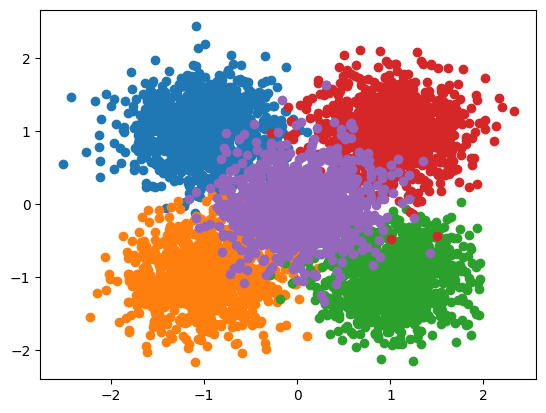

In [23]:
plt.scatter(X[y==0, 0], X[y==0, 1])
plt.scatter(X[y==1, 0], X[y==1, 1])
plt.scatter(X[y==2, 0], X[y==2, 1])
plt.scatter(X[y==3, 0], X[y==3, 1])
plt.scatter(X[y==4, 0], X[y==4, 1])

# Las etiquetas numéricas se exprean en One-Hot Encoding

In [24]:
print(y)
y_cat = to_categorical(y, 5)
print(y_cat)

[4 4 4 ... 2 2 3]
[[0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]
 ...
 [0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]]


# Dividimos el dataset en set de entrenamiento y de prueba

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y_cat, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(X_train.shape[1:])

(4000, 2)
(1000, 2)
(2,)


# Se prepara una capa oculta con 32 neuronas, 2 entradas y una capa de salida con 5 neuronas y activación Softmax

In [26]:
model = Sequential()
model.add(Dense(units = 32, activation='relu', input_shape=X_train.shape[1:]))
model.add(Dense(units = 5, activation='softmax'))
model.compile(Adam(learning_rate=0.1), loss = 'categorical_crossentropy', metrics=['accuracy'])
model.summary()

/Users/joelbecerril/miniconda3/envs/ml_env/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 32)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 261 (1.02 KB)

 Trainable params: 261 (1.02 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
history = model.fit(X, y_cat, verbose=2, batch_size = 50, epochs=100, validation_data=(X_test, y_test))

Epoch 1/100
100/100 - 1s - 12ms/step - accuracy: 0.9002 - loss: 0.2814 - val_accuracy: 0.9120 - val_loss: 0.2334
Epoch 2/100
100/100 - 1s - 8ms/step - accuracy: 0.9108 - loss: 0.2666 - val_accuracy: 0.9020 - val_loss: 0.3093
Epoch 3/100
100/100 - 1s - 8ms/step - accuracy: 0.9148 - loss: 0.2679 - val_accuracy: 0.9270 - val_loss: 0.2123
Epoch 4/100
100/100 - 1s - 8ms/step - accuracy: 0.9146 - loss: 0.2646 - val_accuracy: 0.9350 - val_loss: 0.1858
Epoch 5/100
100/100 - 1s - 8ms/step - accuracy: 0.9078 - loss: 0.2925 - val_accuracy: 0.9080 - val_loss: 0.2812
Epoch 6/100
100/100 - 1s - 8ms/step - accuracy: 0.9030 - loss: 0.2929 - val_accuracy: 0.8820 - val_loss: 0.3403
Epoch 7/100
100/100 - 1s - 8ms/step - accuracy: 0.9128 - loss: 0.2593 - val_accuracy: 0.9160 - val_loss: 0.2444
Epoch 8/100
100/100 - 1s - 8ms/step - accuracy: 0.9058 - loss: 0.3248 - val_accuracy: 0.9370 - val_loss: 0.2215
Epoch 9/100
100/100 - 1s - 8ms/step - accuracy: 0.9094 - loss: 0.2721 - val_accuracy: 0.9220 - val_loss

In [28]:
scores = model.evaluate(X_test, y_test, verbose=1)
print('Test loss:', scores[0])
print('Test accuracy:', scores[1])

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9380 - loss: 0.2107
Test loss: 0.21070492267608643
Test accuracy: 0.9380000233650208


# Verificamos la clasificación de manera gráfica

In [29]:
def plot_multiclass_decision_boundary(X, y, model):
    x_span = np.linspace(min(X[:,0]) - 1, max(X[:,0]) + 1)
    y_span = np.linspace(min(X[:,1]) - 1, max(X[:,1]) + 1)
    xx, yy = np.meshgrid(x_span, y_span)
    grid = np.c_[xx.ravel(), yy.ravel()]
    pred_func = np.argmax(model.predict(grid), axis=-1)
    z = pred_func.reshape(xx.shape)
    plt.contourf(xx, yy, z)

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


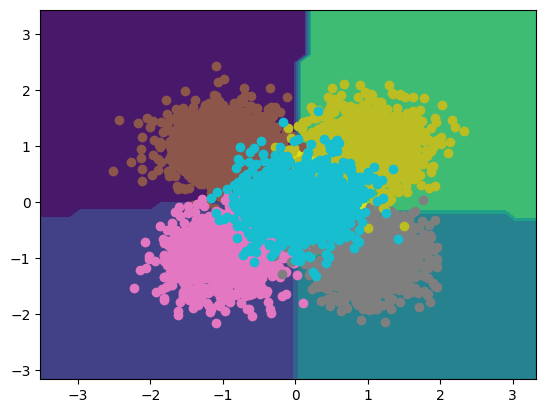

In [30]:
plot_multiclass_decision_boundary(X, y_cat, model)
plt.scatter(X[y==0, 0], X[y==0, 1])
plt.scatter(X[y==1, 0], X[y==1, 1])
plt.scatter(X[y==2, 0], X[y==2, 1])
plt.scatter(X[y==3, 0], X[y==3, 1])
plt.scatter(X[y==4, 0], X[y==4, 1])

plot_multiclass_decision_boundary(X, y_cat, model)
plt.scatter(X[y==0, 0], X[y==0, 1])
plt.scatter(X[y==1, 0], X[y==1, 1])
plt.scatter(X[y==2, 0], X[y==2, 1])
plt.scatter(X[y==3, 0], X[y==3, 1])
plt.scatter(X[y==4, 0], X[y==4, 1])

# Modificación 1
### Se agrega una segunda capa oculta de 16 nodos

In [31]:
model = Sequential()
model.add(Dense(units = 32, activation='relu', input_shape=X_train.shape[1:]))
model.add(Dense(units = 16, activation='relu'))
model.add(Dense(units = 5, activation='softmax'))
model.compile(Adam(learning_rate=0.1), loss = 'categorical_crossentropy', metrics=['accuracy'])
model.summary()

history = model.fit(X, y_cat, verbose=2, batch_size = 50, epochs=100, validation_data=(X_test, y_test))

scores = model.evaluate(X_test, y_test, verbose=1)
print('Test loss:', scores[0])
print('Test accuracy:', scores[1])

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 32)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 709 (2.77 KB)

 Trainable params: 709 (2.77 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
100/100 - 2s - 16ms/step - accuracy: 0.8584 - loss: 0.7467 - val_accuracy: 0.8980 - val_loss: 0.4317
Epoch 2/100
100/100 - 1s - 10ms/step - accuracy: 0.8766 - loss: 0.8587 - val_accuracy: 0.8750 - val_loss: 1.2066
Epoch 3/100
100/100 - 1s - 10ms/step - accuracy: 0.8900 - loss: 0.8458 - val_accuracy: 0.8570 - val_loss: 0.8968
Epoch 4/100
100/100 - 1s - 11ms/step - accuracy: 0.8988 - loss: 0.6911 - val_accuracy: 0.8910 - val_loss: 0.7657
Epoch 5/100
100/100 - 1s - 11ms/step - accuracy: 0.9022 - loss: 0.6234 - val_accuracy: 0.8550 - val_loss: 1.1988
Epoch 6/100
100/100 - 1s - 11ms/step - accuracy: 0.8792 - loss: 0.9298 - val_accuracy: 0.9290 - val_loss: 0.5126
Epoch 7/100
100/100 - 1s - 11ms/step - accuracy: 0.9026 - loss: 0.7713 - val_accuracy: 0.8660 - val_loss: 1.3518
Epoch 8/100
100/100 - 1s - 11ms/step - accuracy: 0.8972 - loss: 0.8652 - val_accuracy: 0.8100 - val_loss: 1.6971
Epoch 9/100
100/100 - 1s - 11ms/step - accuracy: 0.8988 - loss: 0.8245 - val_accuracy: 0.9000 - 

# Modificación 2
### Se agrega otra capa oculta respecto a la modificación anterior

In [32]:
model = Sequential()
model.add(Dense(units = 32, activation='relu', input_shape=X_train.shape[1:]))
model.add(Dense(units = 16, activation='relu'))
model.add(Dense(units = 5, activation='softmax'))
model.compile(Adam(learning_rate=0.1), loss = 'categorical_crossentropy', metrics=['accuracy'])
model.summary()

history = model.fit(X, y_cat, verbose=2, batch_size = 50, epochs=100, validation_data=(X_test, y_test))

scores = model.evaluate(X_test, y_test, verbose=1)
print('Test loss:', scores[0])
print('Test accuracy:', scores[1])

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 32)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 709 (2.77 KB)

 Trainable params: 709 (2.77 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
100/100 - 1s - 14ms/step - accuracy: 0.8686 - loss: 0.5252 - val_accuracy: 0.9180 - val_loss: 0.2944
Epoch 2/100
100/100 - 1s - 9ms/step - accuracy: 0.8636 - loss: 0.8467 - val_accuracy: 0.8880 - val_loss: 0.5977
Epoch 3/100
100/100 - 1s - 9ms/step - accuracy: 0.8890 - loss: 0.9483 - val_accuracy: 0.9210 - val_loss: 0.5072
Epoch 4/100
100/100 - 1s - 9ms/step - accuracy: 0.8868 - loss: 0.9416 - val_accuracy: 0.8940 - val_loss: 0.8346
Epoch 5/100
100/100 - 1s - 9ms/step - accuracy: 0.8384 - loss: 1.7723 - val_accuracy: 0.7230 - val_loss: 6.1938
Epoch 6/100
100/100 - 1s - 10ms/step - accuracy: 0.8506 - loss: 6.8057 - val_accuracy: 0.9360 - val_loss: 3.2748
Epoch 7/100
100/100 - 1s - 9ms/step - accuracy: 0.8838 - loss: 6.6391 - val_accuracy: 0.8570 - val_loss: 11.2411
Epoch 8/100
100/100 - 1s - 9ms/step - accuracy: 0.8852 - loss: 9.6980 - val_accuracy: 0.9100 - val_loss: 6.5705
Epoch 9/100
100/100 - 1s - 9ms/step - accuracy: 0.9092 - loss: 6.8756 - val_accuracy: 0.9160 - val_lo

# Modificación #3
### Se mantiene una sola capa oculta, pero de mayor número de nodos

In [33]:
model = Sequential()
model.add(Dense(units = 64, activation='relu', input_shape=X_train.shape[1:]))
model.add(Dense(units = 5, activation='softmax'))
model.compile(Adam(learning_rate=0.1), loss = 'categorical_crossentropy', metrics=['accuracy'])
model.summary()

history = model.fit(X, y_cat, verbose=2, batch_size = 50, epochs=100, validation_data=(X_test, y_test))

scores = model.evaluate(X_test, y_test, verbose=1)
print('Test loss:', scores[0])
print('Test accuracy:', scores[1])

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 517 (2.02 KB)

 Trainable params: 517 (2.02 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
100/100 - 1s - 12ms/step - accuracy: 0.8890 - loss: 0.3682 - val_accuracy: 0.9260 - val_loss: 0.2134
Epoch 2/100
100/100 - 1s - 8ms/step - accuracy: 0.9036 - loss: 0.3137 - val_accuracy: 0.9110 - val_loss: 0.3184
Epoch 3/100
100/100 - 1s - 8ms/step - accuracy: 0.9090 - loss: 0.2957 - val_accuracy: 0.9140 - val_loss: 0.2729
Epoch 4/100
100/100 - 1s - 8ms/step - accuracy: 0.8978 - loss: 0.4171 - val_accuracy: 0.9330 - val_loss: 0.2319
Epoch 5/100
100/100 - 1s - 8ms/step - accuracy: 0.8962 - loss: 0.4076 - val_accuracy: 0.9010 - val_loss: 0.3678
Epoch 6/100
100/100 - 1s - 8ms/step - accuracy: 0.8978 - loss: 0.4352 - val_accuracy: 0.9220 - val_loss: 0.2956
Epoch 7/100
100/100 - 1s - 9ms/step - accuracy: 0.9078 - loss: 0.3461 - val_accuracy: 0.9340 - val_loss: 0.2223
Epoch 8/100
100/100 - 1s - 9ms/step - accuracy: 0.9040 - loss: 0.3684 - val_accuracy: 0.9340 - val_loss: 0.2081
Epoch 9/100
100/100 - 1s - 8ms/step - accuracy: 0.9004 - loss: 0.3977 - val_accuracy: 0.8960 - val_loss

# Gracias por la atención